## Анализ и прогнозирование временных рядов методами искусственного интеллекта

### **Практическая работа 3. Поиск аномалий во временных рядах.**


#### **3.1 Поиск диссонансов с помощью алгоритма HotSAX**

##### 3.1.1 Загрузка и подготовка данных

В данной будет использоваться временной ряд, состоящий из показаний акселерометра. 
Анализируемый временной ряд, описывает две активности человека - бег и шаг.


In [6]:
!pip install scipy
!pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [7]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from time import time
import pandas as pd

In [8]:
#fixme: Путь
dataset_dir_path = Path('datasets')
data_path = dataset_dir_path/'walk_run.txt'
walk_run = np.loadtxt(data_path)[3000:4000]
data = walk_run
size_sub = 50

В середине временного ряда происходит смена активности (бег заменяет шаг). Нетипичным поведением, которое мы могли бы назвать диссонансами в данном ряде выступает небольшой участок между активностями, когда человек плавно увеличивает скорость шага до бега. В ходе данной работе наша задача выделить с помощью различных алгоритмов границы нашего диссонанса.

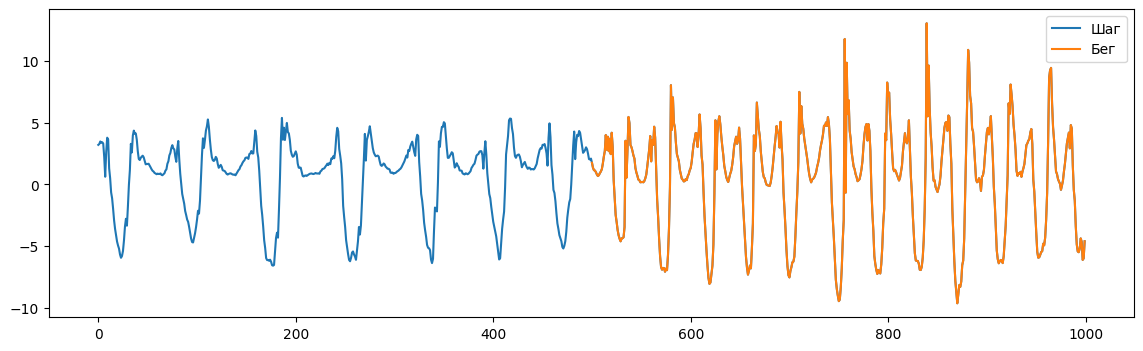

In [10]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

In [11]:
results={}
times={}

##### 3.1.2 Реализация полного перебора

Приводится пример кода для нахождения топ 5 диссонансов с помощью реализации полного беребора.
Вам необходимо добавить код для сбора времени обработки данных.

In [14]:
from modules.saxpy.discord import find_discords_brute_force
start = time()
discords_brute_force= np.stack(find_discords_brute_force(data[:], 50, 5))
end = time()

In [15]:
time_brute_force = end - start
time_brute_force

73.97391128540039

In [16]:
discords_brute_force

array([[477.        ,   5.88100934],
       [412.        ,   5.32704317],
       [195.        ,   3.39426635],
       [577.        ,   3.35554403],
       [278.        ,   3.10959389]])

In [17]:
results['brute_force'] = discords_brute_force
times['brute_force'] = time_brute_force

##### 3.1.3 HotSAX

Используя [реализацию](https://github.com/seninp/saxpy/blob/master/saxpy/hotsax.py) найдите топ 5 диссонансов ряда.
Произведите замер времени работы.

In [20]:
from modules.saxpy.hotsax import find_discords_hotsax

start = time()
discords_hotsax = np.stack(find_discords_hotsax(data[:], 50, 5))
end = time()

In [21]:
time_hotsax = end - start
time_hotsax

1.5389878749847412

In [22]:
discords_hotsax

array([[477.        ,   5.88100934],
       [412.        ,   5.32704317],
       [195.        ,   3.39426635],
       [577.        ,   3.35554403],
       [278.        ,   3.10959389]])

In [23]:
results['hotsax'] = discords_hotsax
times['hotsax'] = time_hotsax

##### 3.1.4 Визаулизация

In [25]:
results

{'brute_force': array([[477.        ,   5.88100934],
        [412.        ,   5.32704317],
        [195.        ,   3.39426635],
        [577.        ,   3.35554403],
        [278.        ,   3.10959389]]),
 'hotsax': array([[477.        ,   5.88100934],
        [412.        ,   5.32704317],
        [195.        ,   3.39426635],
        [577.        ,   3.35554403],
        [278.        ,   3.10959389]])}

In [26]:
times

{'brute_force': 73.97391128540039, 'hotsax': 1.5389878749847412}

Вам необходимо реализовать код позволяющий:
1. Вывести на одном графике ряд и его диссонансы
2. Столбчатую диаграмму времени работы обоих алгоритмов
   
Постройте графики для обоих алгоритмов и сравните полученные результаты.

Пример графика:

![first_graf](pics/fig_ex_1.png)

In [28]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

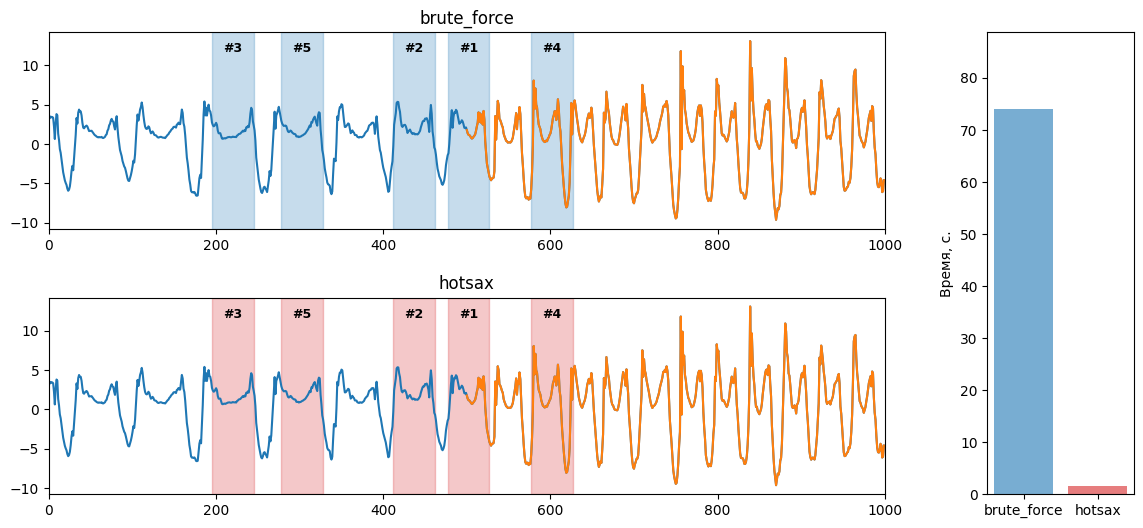

In [29]:
bf_rows = results['brute_force']
hs_rows = results['hotsax']

bf_idx = [int(x[0]) for x in bf_rows]
bf_scores = [float(x[1]) for x in bf_rows]
hs_idx = [int(x[0]) for x in hs_rows]
hs_scores = [float(x[1]) for x in hs_rows]

alg_names = ['brute_force', 'hotsax']
alg_times = [times['brute_force'], times['hotsax']]

n = len(data)
half = n // 2

fig = plt.figure(figsize=(14,6))
gs = gridspec.GridSpec(2, 3, width_ratios=[1,1,0.4], height_ratios=[1,1], wspace=0.35, hspace=0.35)

ax_bf = fig.add_subplot(gs[0, 0:2])
ax_hs = fig.add_subplot(gs[1, 0:2])
ax_bar = fig.add_subplot(gs[:, 2])

def plot_series(ax):
    ax.plot(data, label='Шаг')
    ax.plot(np.arange(half, n), data[half:], label='Бег')
    ax.set_xlim(0, n)

plot_series(ax_bf)
ax_bf.set_title('brute_force')

plot_series(ax_hs)
ax_hs.set_title('hotsax')

def highlight_windows(ax, indices, scores, window, color='C0', alpha=0.25):
    ymin, ymax = ax.get_ylim()
    height = ymax - ymin
    for k, (idx, score) in enumerate(zip(indices, scores)):
        x0 = idx
        rect = Rectangle((x0, ymin), window, height, color=color, alpha=alpha, zorder=1)
        ax.add_patch(rect)
        ax.text(x0 + window/2, ymax - 0.05*height,
                f"#{k+1}",
                ha='center', va='top', fontsize=9, fontweight='bold', zorder=2)

highlight_windows(ax_bf, bf_idx, bf_scores, size_sub, color='C0', alpha=0.25)
highlight_windows(ax_hs, hs_idx, hs_scores, size_sub, color='C3', alpha=0.25)

bars = ax_bar.bar(alg_names, alg_times, alpha=0.6, color=['C0', 'C3'])
ax_bar.set_ylabel('Время, с.')
ax_bar.set_ylim(0, max(alg_times)*1.2)

plt.show()

##### 3.1.5 Такси NY

Произведите поиск диссонансов с помощью обоих алгоритмов на наборе данных, содержащим информацию о среднем числе пассажиров в NY. Отобразите найденные диссонансы обоими алгоритмами. 

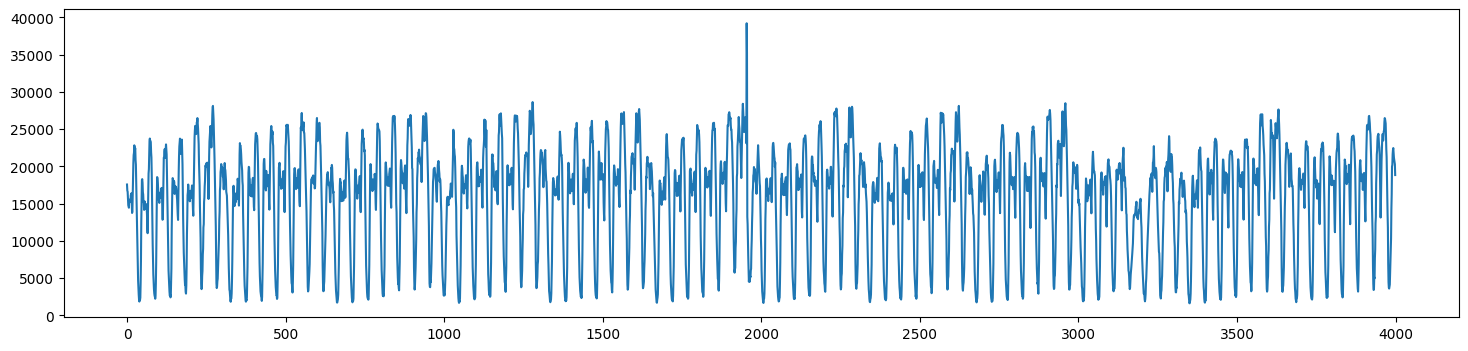

In [31]:
nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64)
fig = plt.figure(figsize=(18, 4))
plt.plot(nyc_taxi)

In [32]:
results_nyc_taxi={}
times_nyc_taxi={}

In [33]:
from modules.saxpy.discord import find_discords_brute_force

start = time()
discords_nyc_taxi_brute_force= np.stack(find_discords_brute_force(nyc_taxi[:], 50, 5))
end = time()

In [34]:
time_nyc_taxi_brute_force = end - start
time_nyc_taxi_brute_force

1730.3585538864136

In [35]:
discords_nyc_taxi_brute_force

array([[1.91000000e+03, 3.52681530e+00],
       [3.12000000e+03, 3.40233164e+00],
       [3.18300000e+03, 2.64204097e+00],
       [3.23700000e+03, 2.22922775e+00],
       [9.63000000e+02, 1.61152765e+00]])

In [36]:
results_nyc_taxi['brute_force'] = discords_nyc_taxi_brute_force
times_nyc_taxi['brute_force'] = time_nyc_taxi_brute_force

In [37]:
from modules.saxpy.hotsax import find_discords_hotsax

start = time()
discords_nyc_taxi_hotsax = np.stack(find_discords_hotsax(nyc_taxi[:], 50, 5))
end = time()

In [38]:
time_nyc_taxi_hotsax = end - start
time_nyc_taxi_hotsax

6.81083345413208

In [39]:
discords_nyc_taxi_hotsax

array([[1.91000000e+03, 3.52681530e+00],
       [3.12000000e+03, 3.40233164e+00],
       [3.18300000e+03, 2.64204097e+00],
       [3.23700000e+03, 2.22922775e+00],
       [9.63000000e+02, 1.61152765e+00]])

In [40]:
results_nyc_taxi['hotsax'] = discords_nyc_taxi_hotsax
times_nyc_taxi['hotsax'] = time_nyc_taxi_hotsax

In [41]:
results_nyc_taxi

{'brute_force': array([[1.91000000e+03, 3.52681530e+00],
        [3.12000000e+03, 3.40233164e+00],
        [3.18300000e+03, 2.64204097e+00],
        [3.23700000e+03, 2.22922775e+00],
        [9.63000000e+02, 1.61152765e+00]]),
 'hotsax': array([[1.91000000e+03, 3.52681530e+00],
        [3.12000000e+03, 3.40233164e+00],
        [3.18300000e+03, 2.64204097e+00],
        [3.23700000e+03, 2.22922775e+00],
        [9.63000000e+02, 1.61152765e+00]])}

In [42]:
times_nyc_taxi

{'brute_force': 1730.3585538864136, 'hotsax': 6.81083345413208}

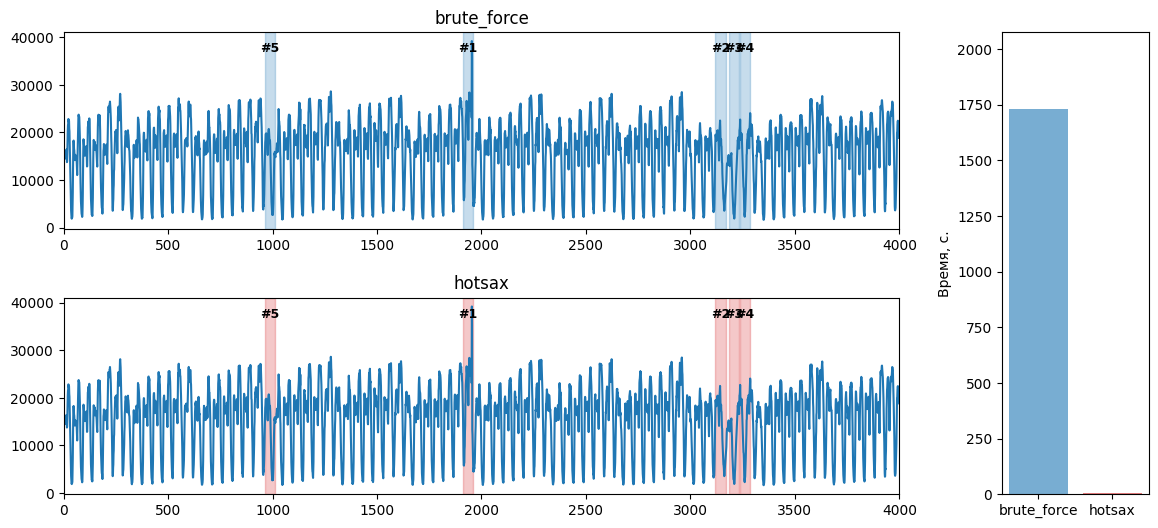

In [43]:
bf_rows = results_nyc_taxi['brute_force']
hs_rows = results_nyc_taxi['hotsax']

bf_idx = [int(x[0]) for x in bf_rows]
bf_scores = [float(x[1]) for x in bf_rows]
hs_idx = [int(x[0]) for x in hs_rows]
hs_scores = [float(x[1]) for x in hs_rows]

alg_names = ['brute_force', 'hotsax']
alg_times = [times_nyc_taxi['brute_force'], times_nyc_taxi['hotsax']]

n = len(nyc_taxi)

fig = plt.figure(figsize=(14,6))
gs = gridspec.GridSpec(2, 3, width_ratios=[1,1,0.4], height_ratios=[1,1], wspace=0.35, hspace=0.35)

ax_bf = fig.add_subplot(gs[0, 0:2])
ax_hs = fig.add_subplot(gs[1, 0:2])
ax_bar = fig.add_subplot(gs[:, 2])

def plot_series(ax):
    ax.plot(nyc_taxi, label='Ряд')
    ax.set_xlim(0, n)

plot_series(ax_bf)
ax_bf.set_title('brute_force')

plot_series(ax_hs)
ax_hs.set_title('hotsax')

def highlight_windows(ax, indices, scores, window, color='C0', alpha=0.25):
    ymin, ymax = ax.get_ylim()
    height = ymax - ymin
    for k, (idx, score) in enumerate(zip(indices, scores)):
        x0 = idx
        rect = Rectangle((x0, ymin), window, height, color=color, alpha=alpha, zorder=1)
        ax.add_patch(rect)
        ax.text(x0 + window/2, ymax - 0.05*height,
                f"#{k+1}",
                ha='center', va='top', fontsize=9, fontweight='bold', zorder=2)

highlight_windows(ax_bf, bf_idx, bf_scores, size_sub, color='C0', alpha=0.25)
highlight_windows(ax_hs, hs_idx, hs_scores, size_sub, color='C3', alpha=0.25)

bars = ax_bar.bar(alg_names, alg_times, alpha=0.6, color=['C0', 'C3'])
ax_bar.set_ylabel('Время, с.')
ax_bar.set_ylim(0, max(alg_times)*1.2)

plt.show()

#### **3.2 Поиск диссонансов с помощью алгоритма DRAG**

In [45]:
!pip install stumpy==1.11.1


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [46]:
import stumpy
from stumpy import core, config
from stumpy.scrump import _prescrump


Как мы помним из лекций:

**Диапазонный диссонанс** – подпоследовательность ряда, расстояние от которой до ее ближайшего соседа не ниже заданного порога. 

Основными параметрами при поисках диссонансов являются:
- $m$ - длина диссонанса
- $r$ - пороговое значение расстояния подпоследовательности ряда, до его ближайшего соседа


In [48]:
from modules.drag import find_candidates, DRAG

Для поиска диссонансов в данной части практической работы мы воспользуемся алгоритмом **DRAG (Discord Range Aware Gathering)**.
Для начала воспользуемся данным алгоритмом, чтобы найти диссонансы в наборе данных содержащем активность человека.

In [50]:
data = walk_run

Длину искомого диссонанса, как и для предыдущих алгоритмов, мы установим равно 50 точек.
Пороговое значение мы установим равным большим, чтобы узнать, как алгоритм отреагирует на большие значения данного параметра.

In [52]:
m = 50 
r = 10
idxs, _, _ = DRAG(data,m,r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 0


Как вы можете видеть мы установили слишком большое пороговое значение, алгоритму не удалось выделить ни одного диссонанса. Попробуем уменьшить пороговое значение до 1, чтобы улучшить результат. 

In [54]:
m = 50 
r = 1
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 50


In [55]:
m = 50 
r = 3
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 9


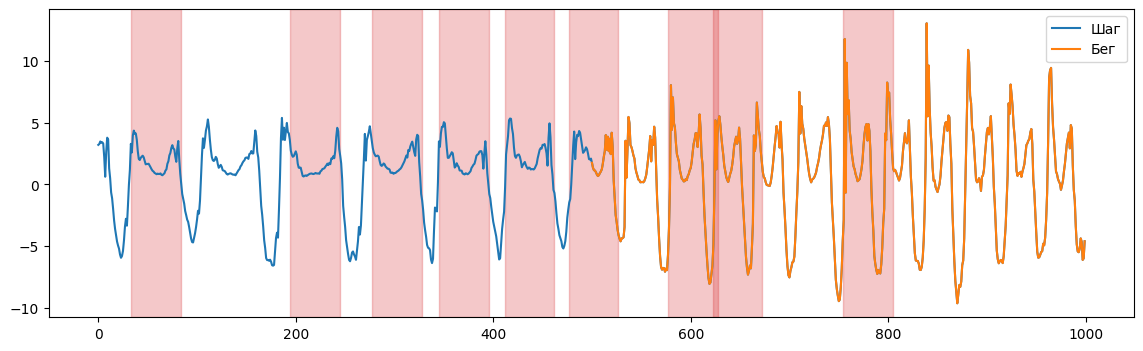

In [56]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

ymin, ymax = ax.get_ylim()
height = ymax - ymin

for idx in idxs:
    rect = Rectangle((idx-0.5, ymin), m, height, alpha=0.25, color='C3', zorder=1)
    ax.add_patch(rect)

При такой комбинации параметров, улучшить ситуацию не получилось. Алгоритм выделил слишком большое количество диссонансов, часть которых является ложными диссонансами и не будут информативными для нас.

Произведите подобные эксперименты с набором данных такси NY. Постройте графики демонстрирующие найденные диссонансы. Пример Графика:
![second-graph](pics/fig_ex_2.png)

In [59]:
data = nyc_taxi

In [60]:
m = 50 
r = 3
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 4


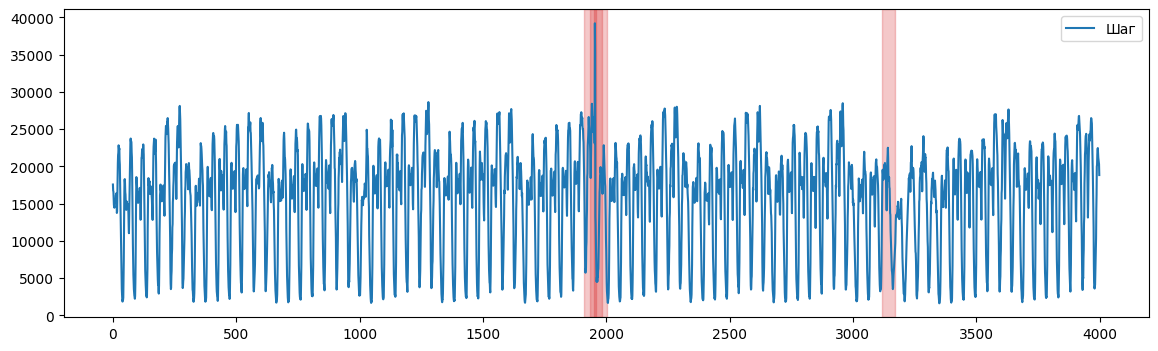

In [61]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.legend()

ymin, ymax = ax.get_ylim()
height = ymax - ymin

for idx in idxs:
    rect = Rectangle((idx-0.5, ymin), m, height, alpha=0.25, color='C3', zorder=1)
    ax.add_patch(rect)

Чтобы разобраться, почему так происходит и как работает данный алгоритм, ниже мы реализуем все этапы алгоритма DRAG.

Как мы помним из лекций алгоритм DRAG содержит два этапа:

1. Отбор - За одно сканирование ряда сформировать множество кандидатов в диссонансы.
2. Очистка - За одно сканирование ряда отбросить кандидатов, которые являются ложными диссонансами.

##### 3.2.1 Отбор кандидатов

Первым этапом обработки данных является отбор множества потенциальных кандидатов. Мы выбираем из всего множества подпоследовательностей ряда такие, для которых расстояние до правых ближайших соседей больше параметра $r$.

In [64]:
data = walk_run

In [65]:
#выбирем более реальное значение для порога
r = 3

In [66]:
T, M_T, Σ_T = core.preprocess(data, m)
#формируем массив длинной равной длине  исходного ряда - m + 1, 
#элемент массива является истинным, 
#в том случае если подпоследовательность является потенциальным кандидатом
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
#находим индексы потенциальных кандидатов
cand_index = np.flatnonzero(is_cands)

In [67]:
print(f'{len(cand_index)} {len(cand_index)/len(data)*100} %')

113 11.3 %


Во время отбора кандидатов нам удалось выделить около 113 подпоследовательностей(около 11.3%), которые мы бы могли назвать потенциальными диссонансами.
Это большой процент, который не может нас устраивать как конечный результат.
Если посмотреть на рисунок ниже, мы увидим, что большая часть потенциальных диссонансов расположена в районе смены активности. 
К сожалению пресутсвуют и ложные диссонансы, которые случайным образом попали в данный список.

Сформируйте график найденных диссонансов

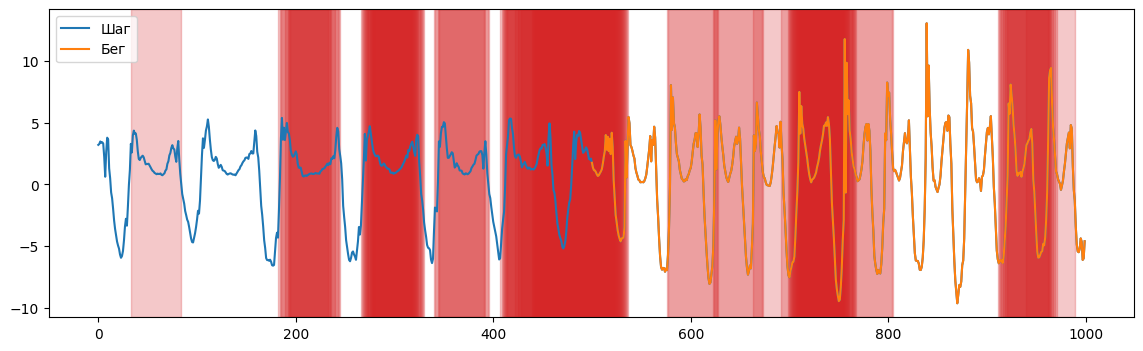

In [70]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

ymin, ymax = ax.get_ylim()
height = ymax - ymin

for idx in cand_index:
    rect = Rectangle((idx-0.5, ymin), m, height, alpha=0.25, color='C3', zorder=1)
    ax.add_patch(rect)

##### 3.2.2 Очистка кандидатов
Как уже упоминалось выше, 11.3% слишком большой процент диссонансов.
Для уменьшения числа потенциальных кандидатов произведем очистку от ложных диссонансов, путем сравнения расстояния до левых ближайших соседей потенциальных диссонансов с порогом $r$.


In [72]:
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
cands = np.flatnonzero(is_cands)

In [73]:
len(cands)/len(data)*100

2.9000000000000004

Сформируйте график найденных диссонансов

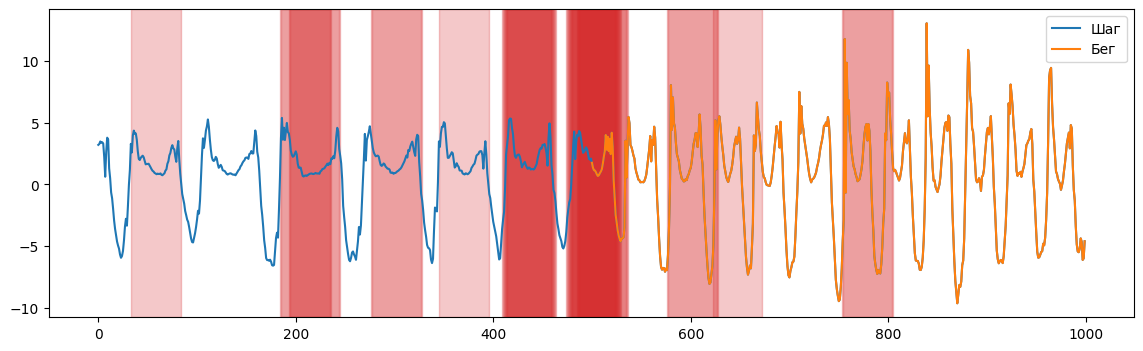

In [75]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

ymin, ymax = ax.get_ylim()
height = ymax - ymin

for idx in cands:
    rect = Rectangle((idx-0.5, ymin), m, height, alpha=0.25, color='C3', zorder=1)
    ax.add_patch(rect)

Нам удалось сократить число диссонансов до 2.9%. Если проанализировать рисунок, то можно заметить, что большая их часть является тривиальными повторениями подпоследовательности в области смены активности. На следующем шаге избавимся от них.

In [77]:
from modules.drag import refine_candidates
discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)
len(discords_idx)/len(data)*100

0.8999999999999999

Сформируйте график найденных диссонансов

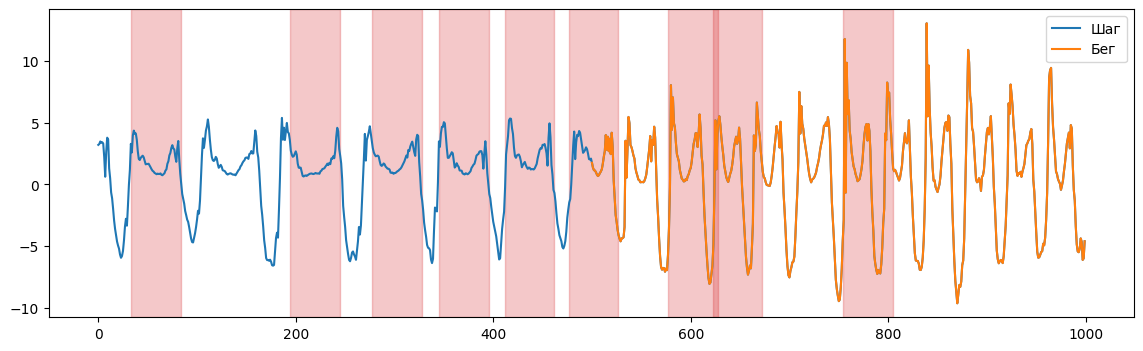

In [79]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

ymin, ymax = ax.get_ylim()
height = ymax - ymin

for idx in discords_idx:
    rect = Rectangle((idx-0.5, ymin), m, height, alpha=0.25, color='C3', zorder=1)
    ax.add_patch(rect)

##### 3.2.3 Подбор параметров

Реализуйте перебор параметров $m$ и $r$. Подберете параметры таким образом, чтобы алгоритм обнаружил только те диссонансы, которые связаны со сменой активности. Сделайте вывод о том, как эти параметры влияют на качество работы модели.
Подберите оптимальные параметры алгоритма для набора данных такси NY. 
Визуализируйте результаты для разных комбинаций. Сделайте выводы.


In [82]:
data = nyc_taxi

1.5 25 26


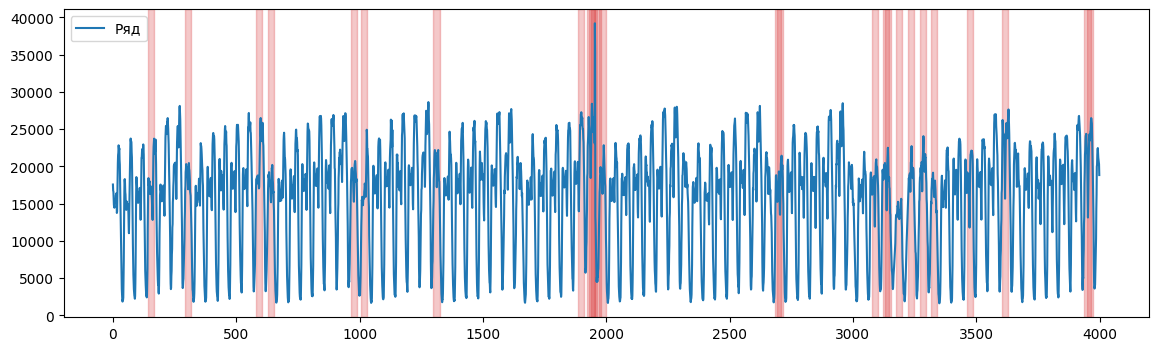

2.0 25 15


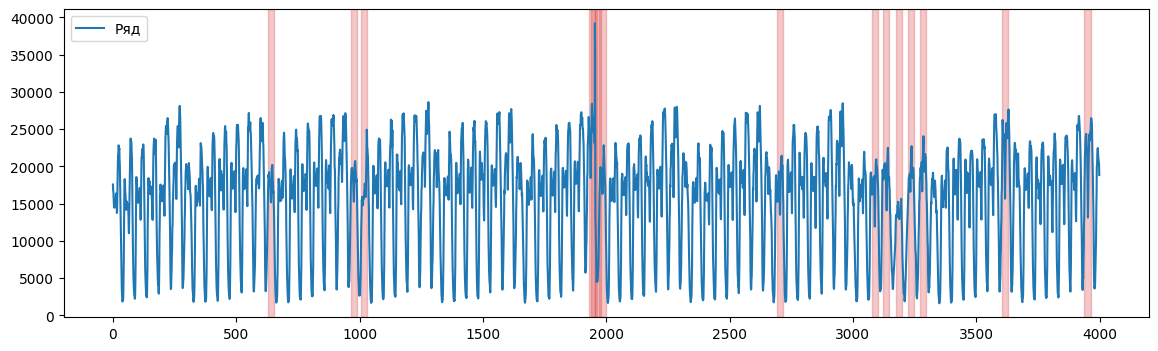

2.5 25 6


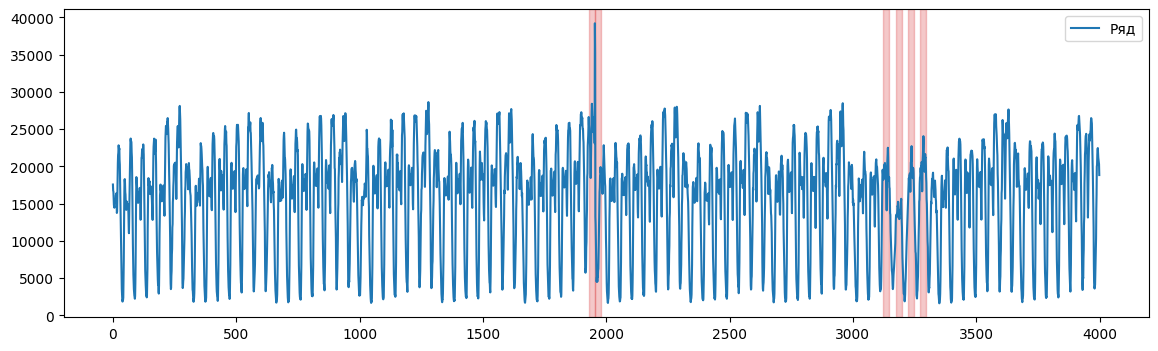

3.0 25 4


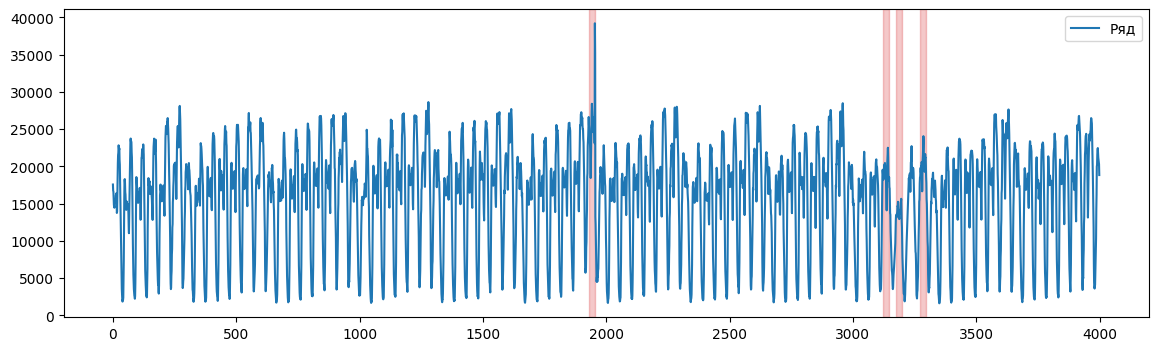

3.5 25 2


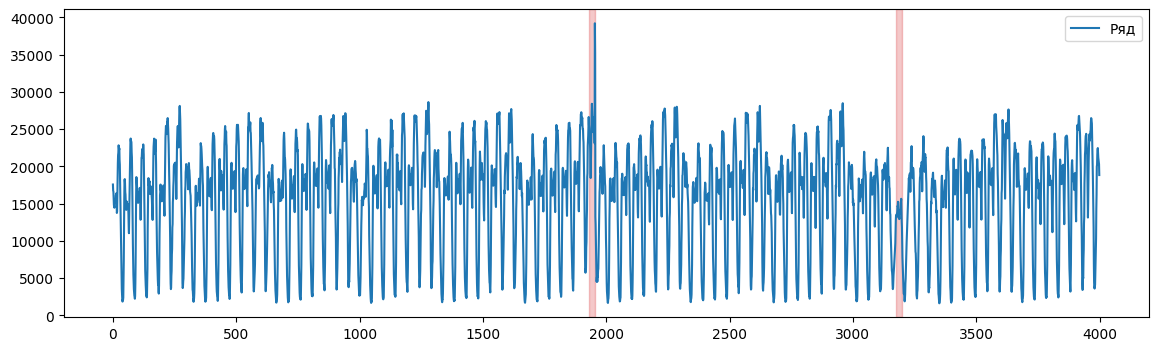

4.0 25 1


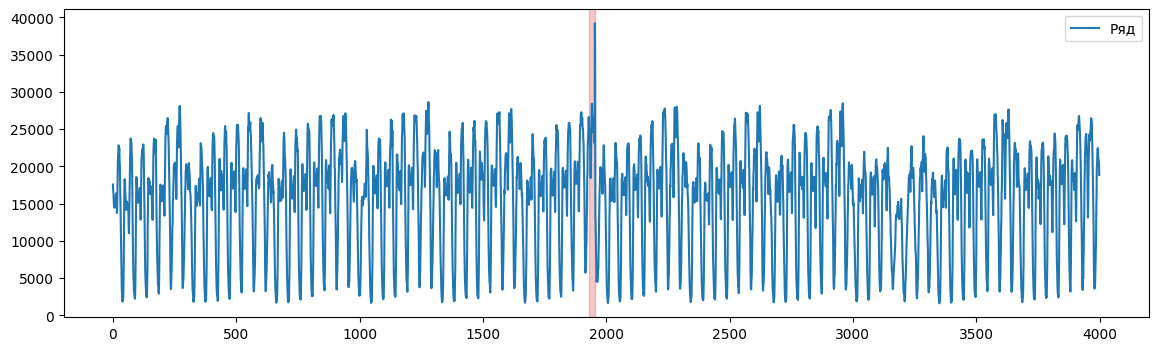

1.5 50 17


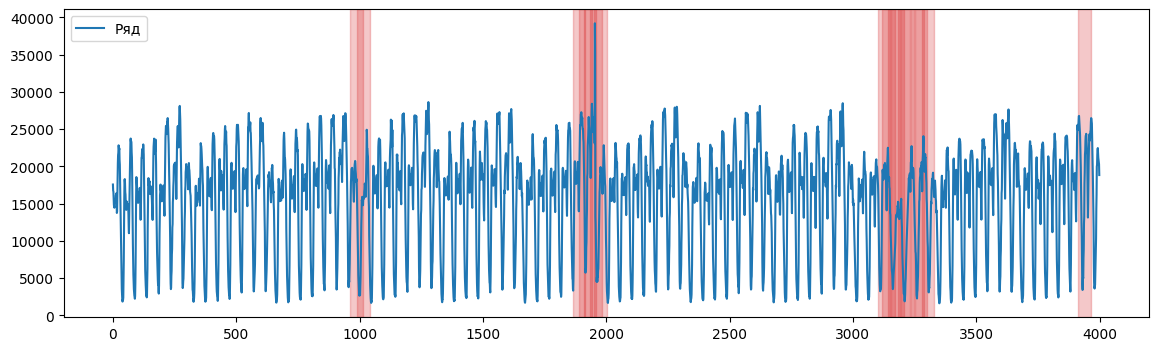

2.0 50 8


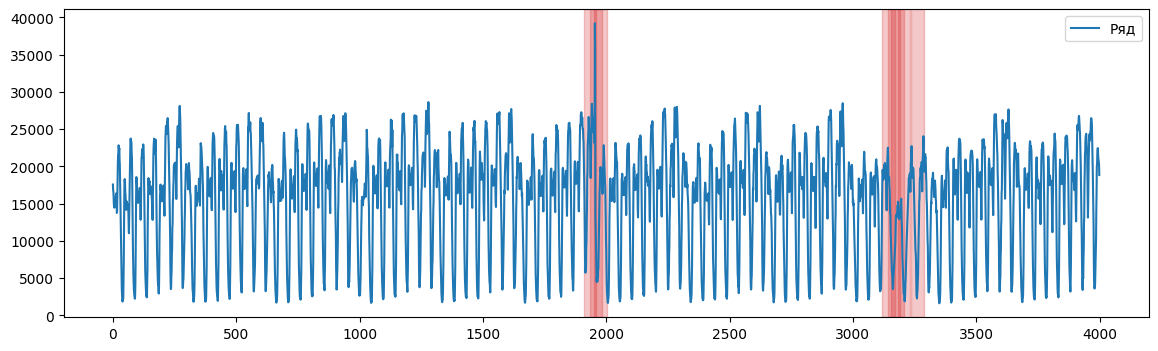

2.5 50 7


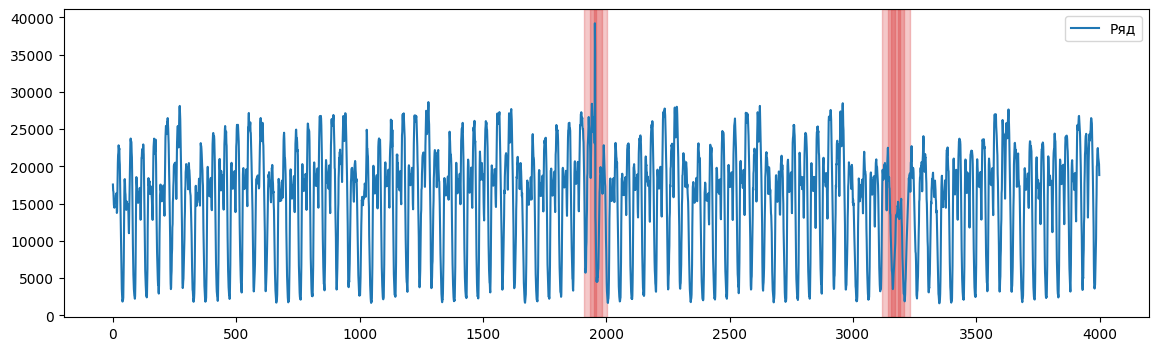

3.0 50 4


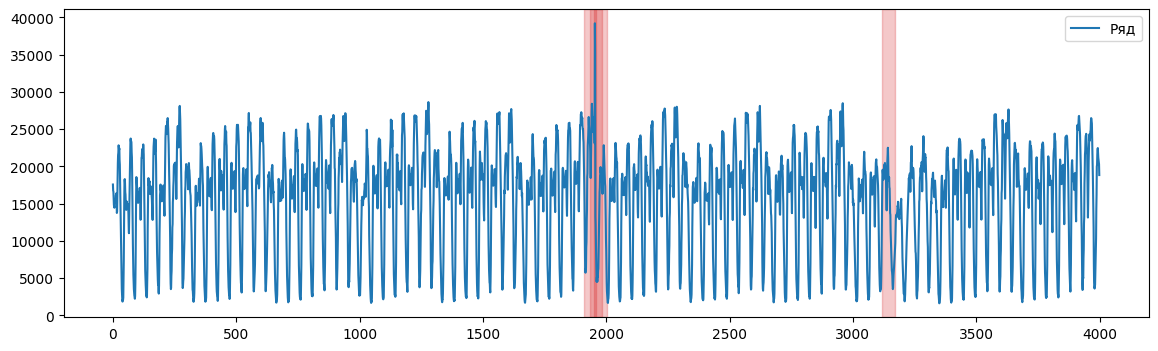

3.5 50 1


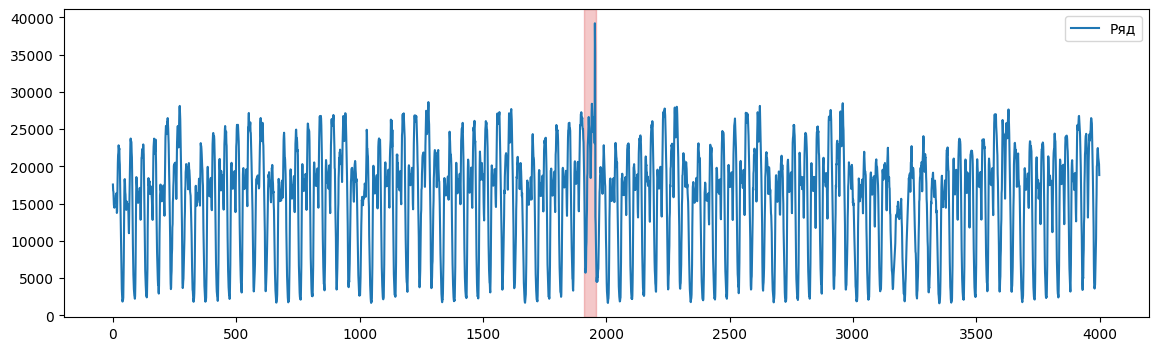

4.0 50 0
1.5 65 22


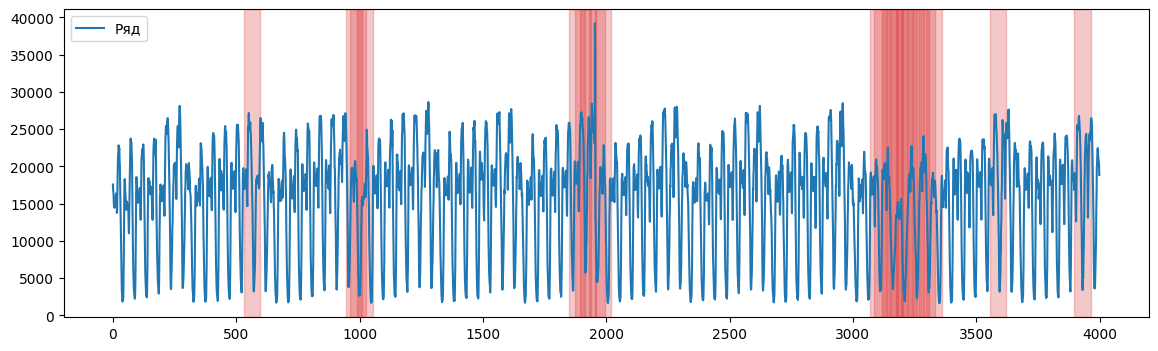

2.0 65 14


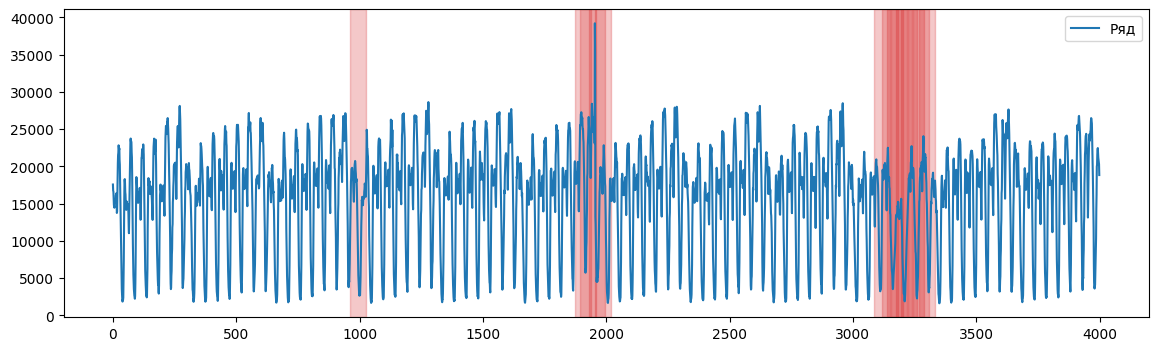

2.5 65 8


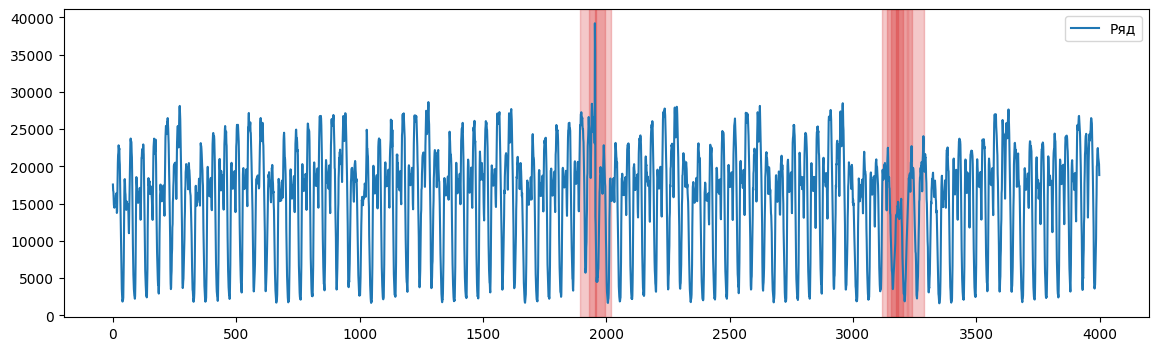

3.0 65 7


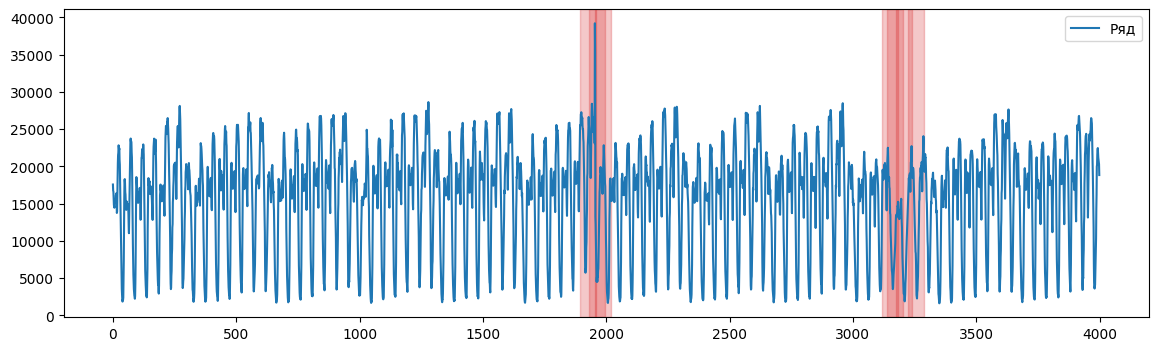

3.5 65 4


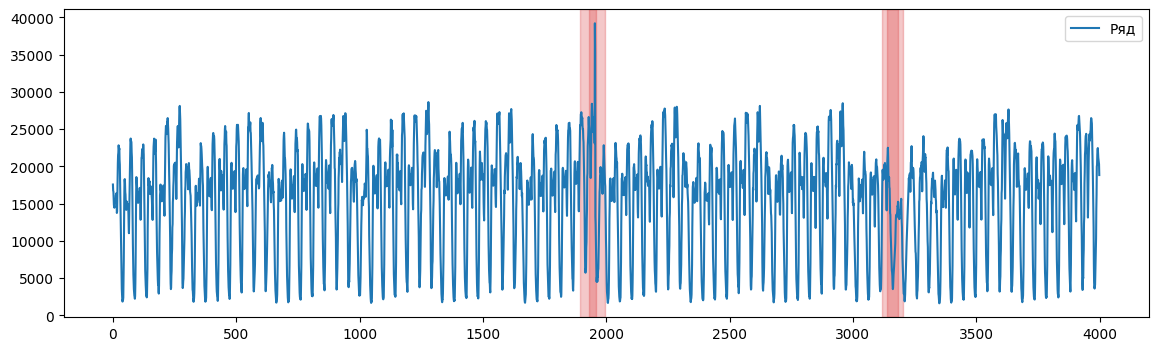

4.0 65 2


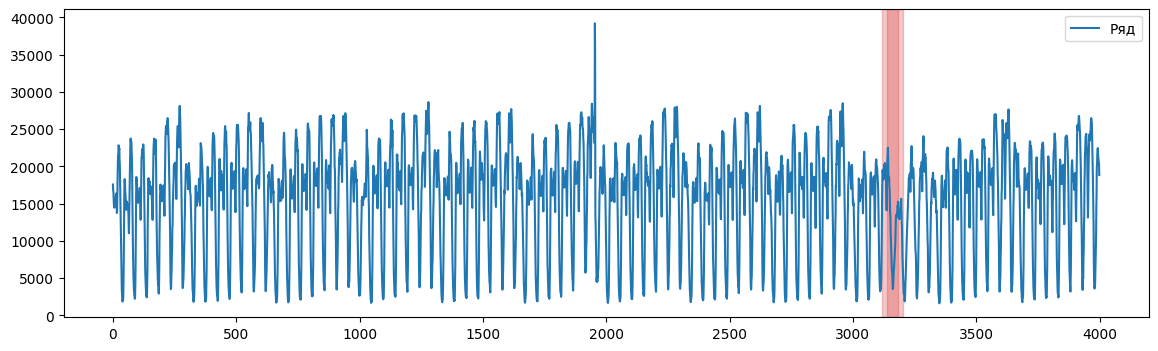

1.5 80 30


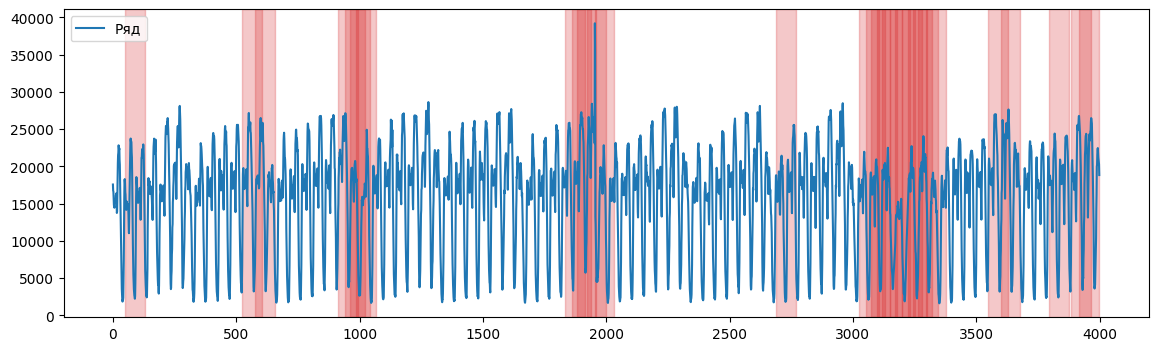

2.0 80 14


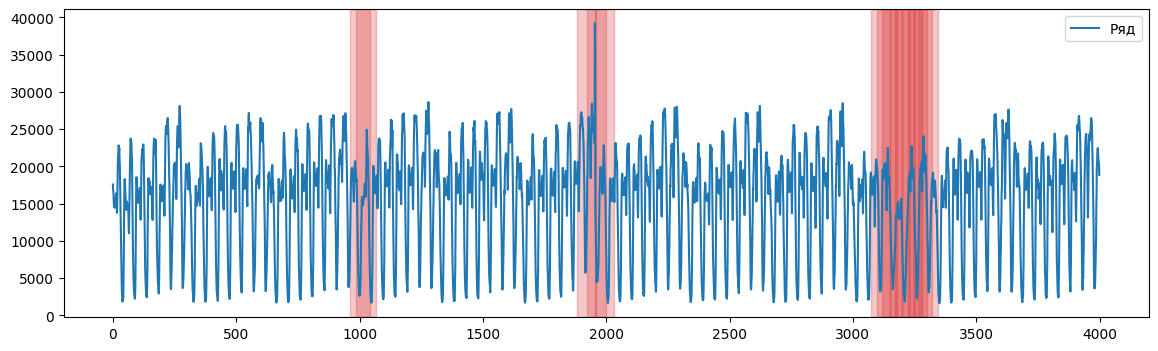

2.5 80 10


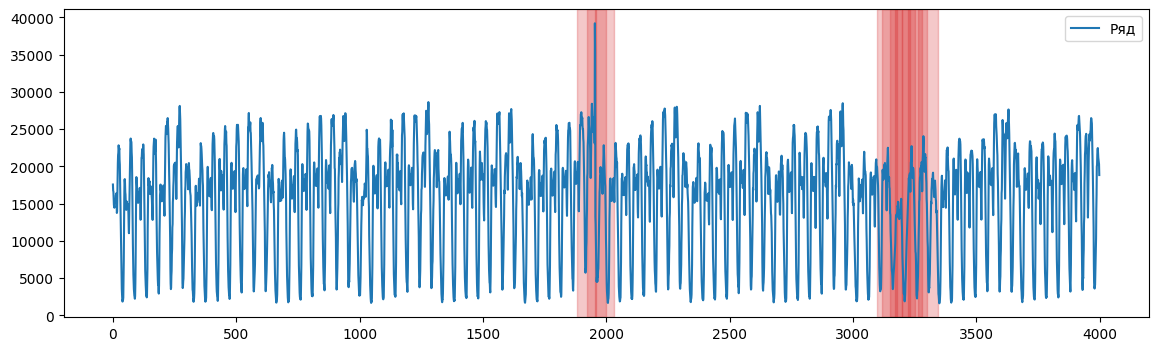

3.0 80 8


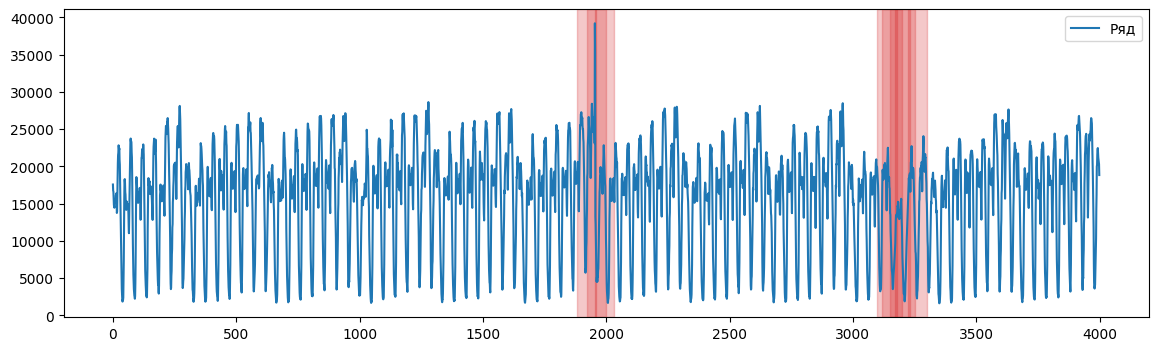

3.5 80 8


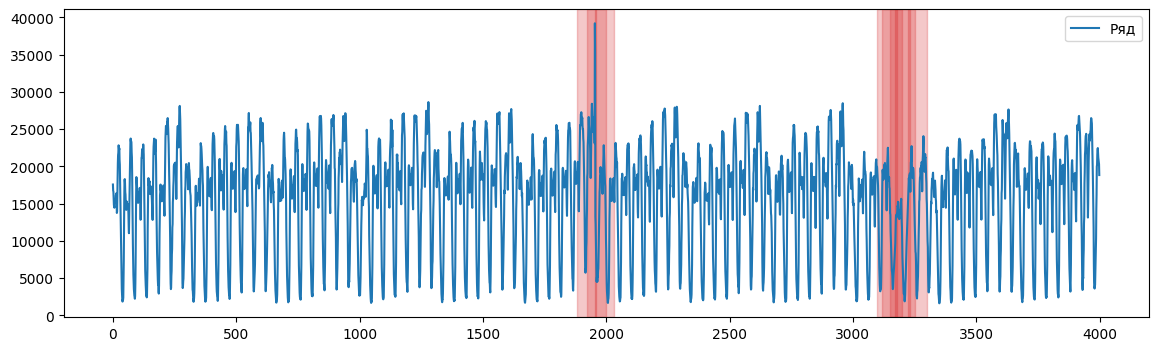

4.0 80 4


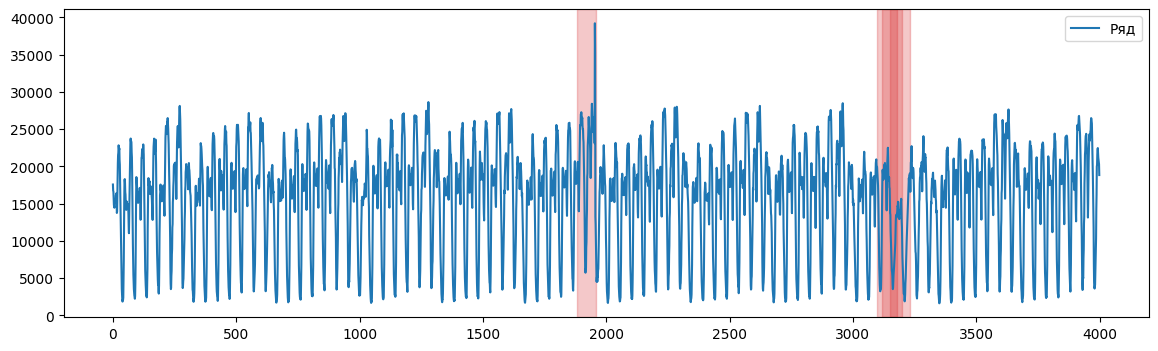

1.5 95 28


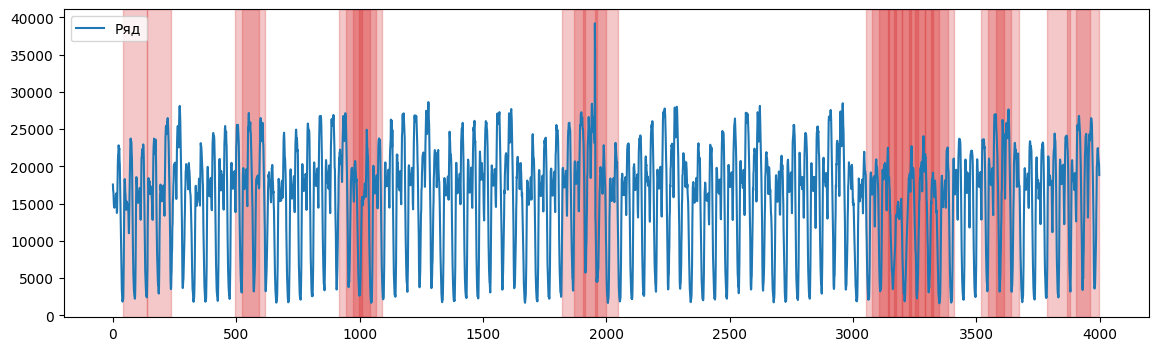

2.0 95 16


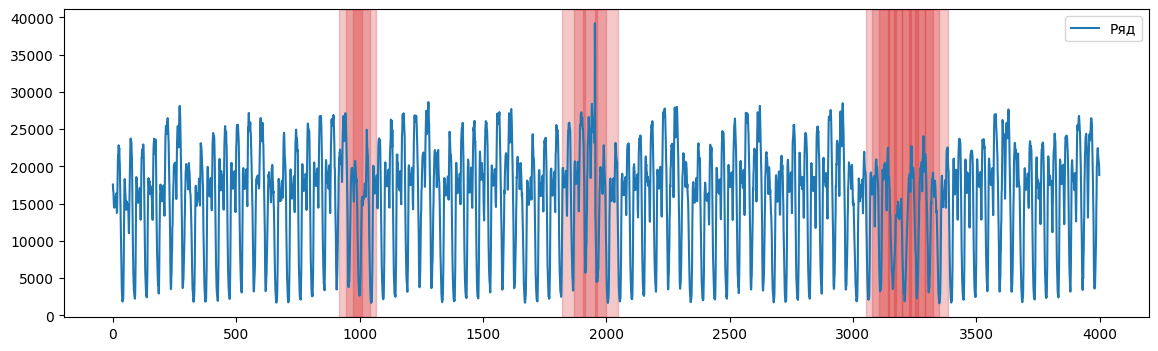

2.5 95 9


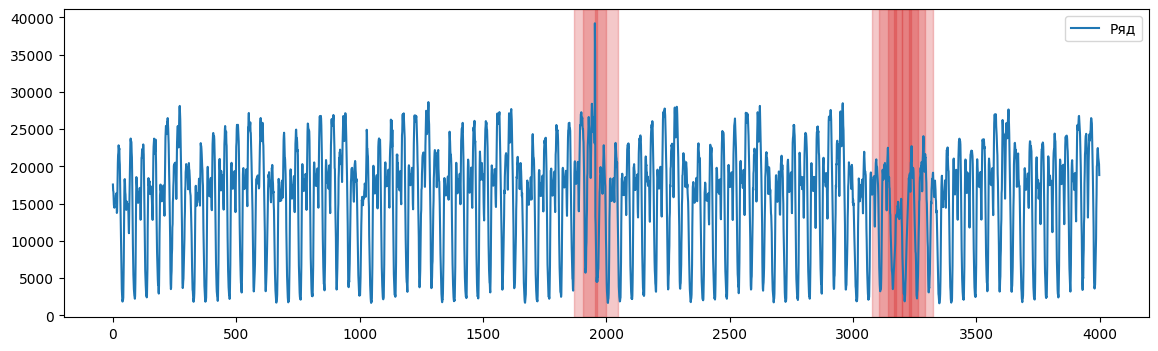

3.0 95 9


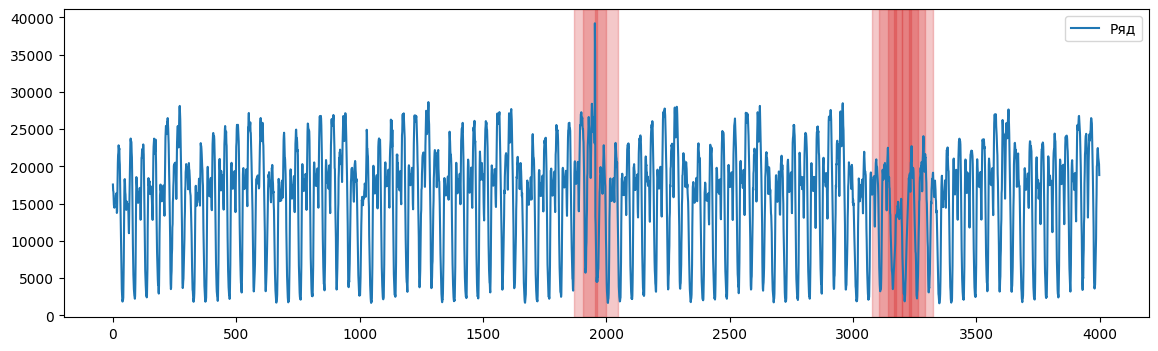

3.5 95 8


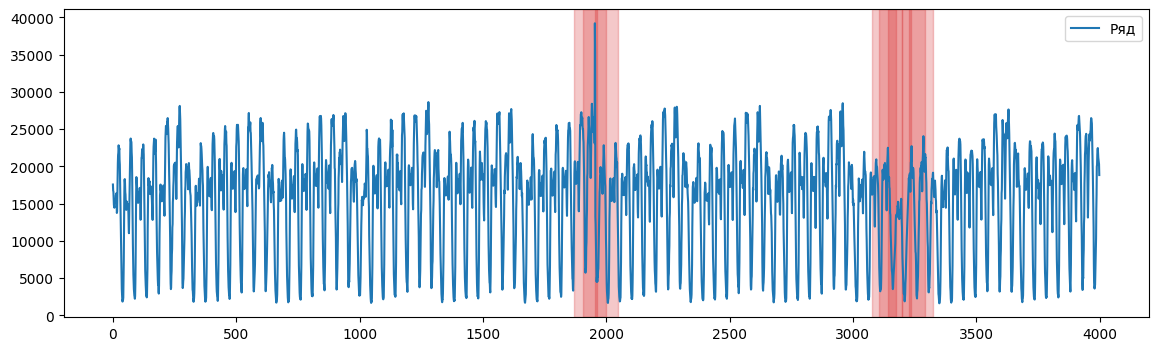

4.0 95 6


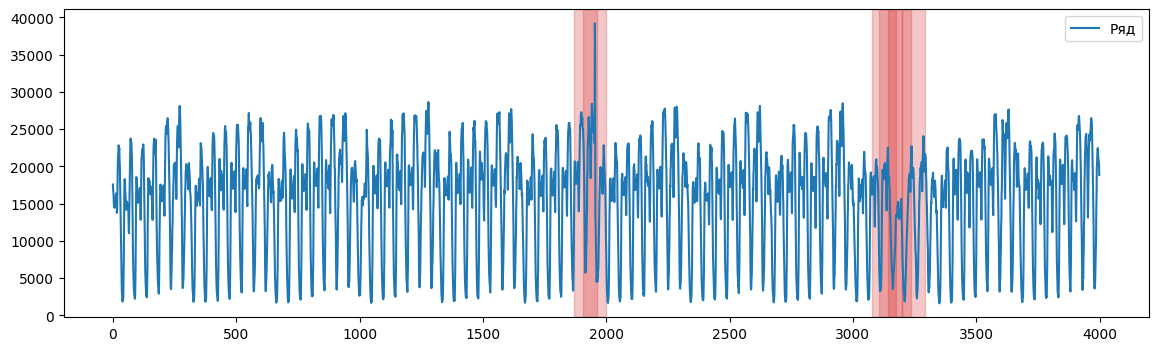

1.5 110 36


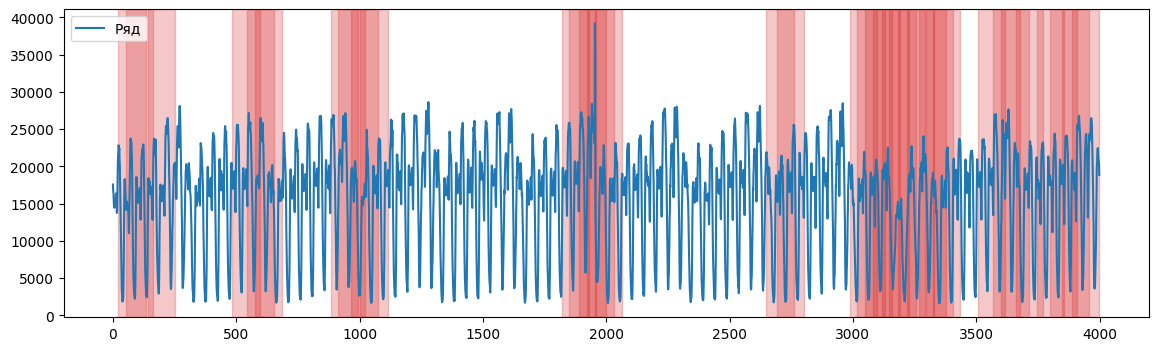

2.0 110 16


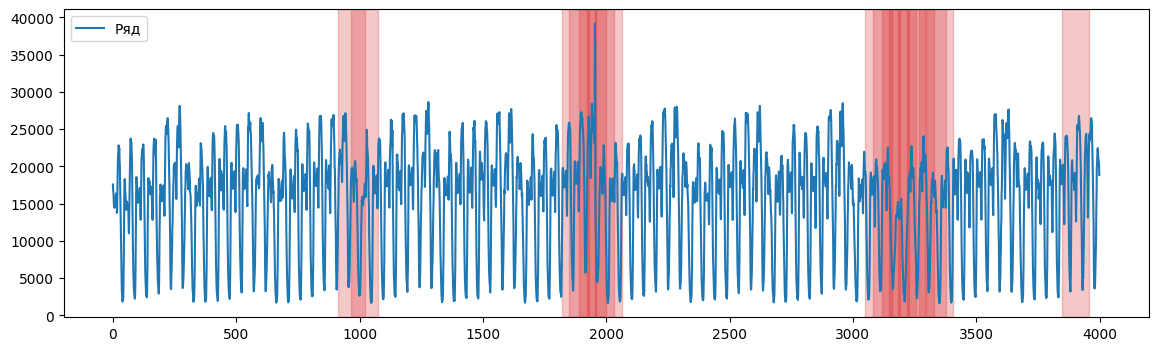

2.5 110 11


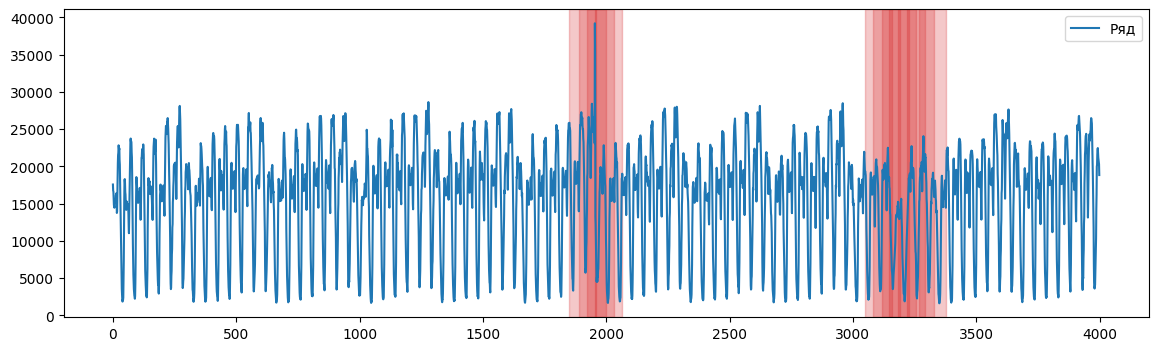

3.0 110 9


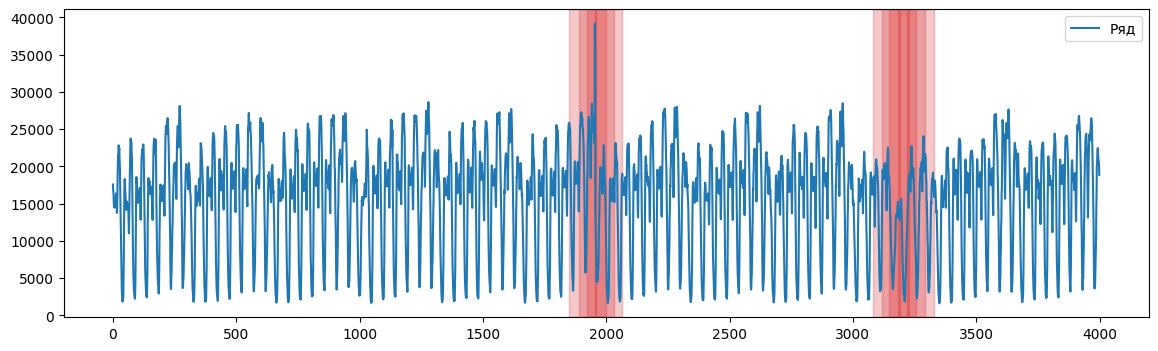

3.5 110 9


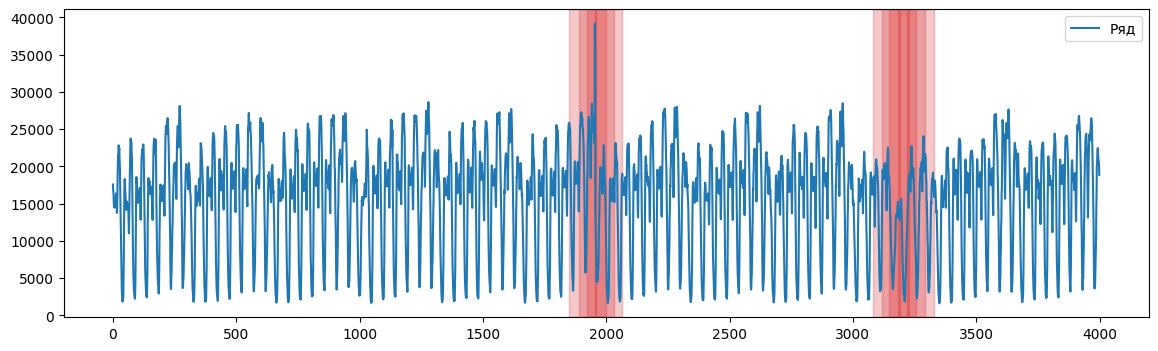

4.0 110 7


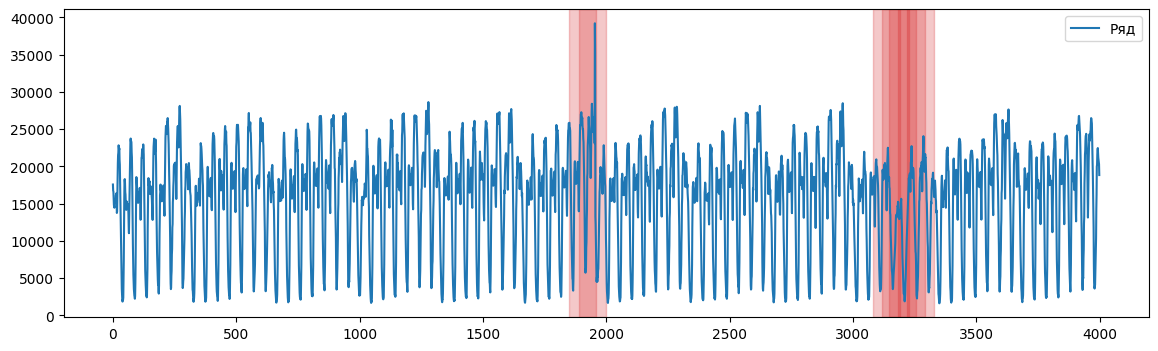

1.5 125 38


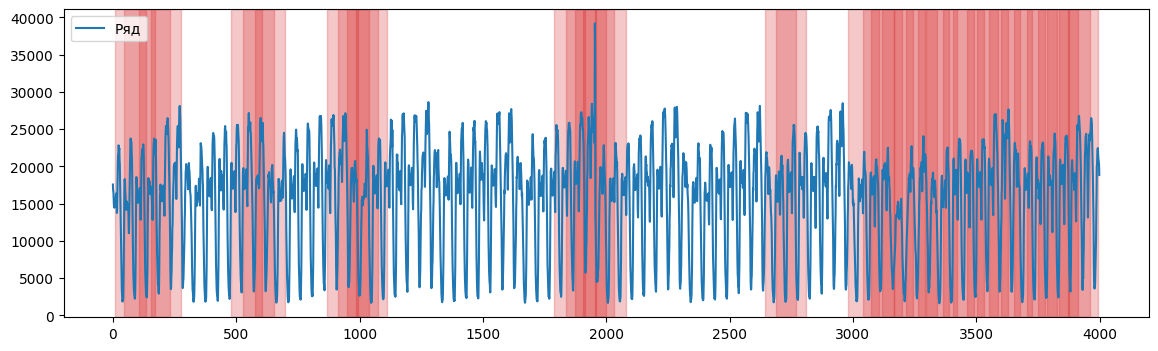

2.0 125 18


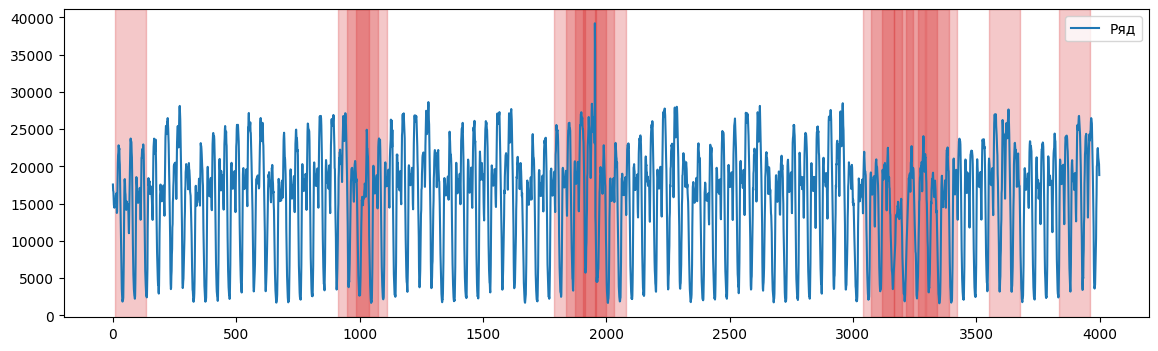

2.5 125 10


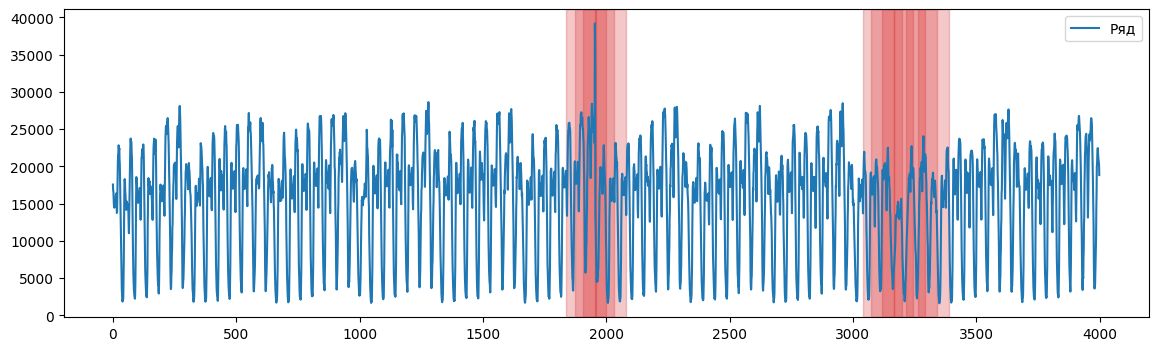

3.0 125 10


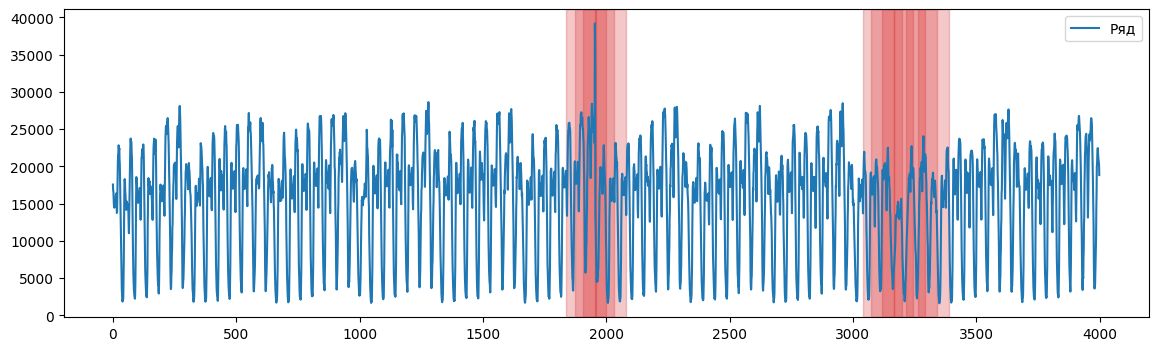

3.5 125 8


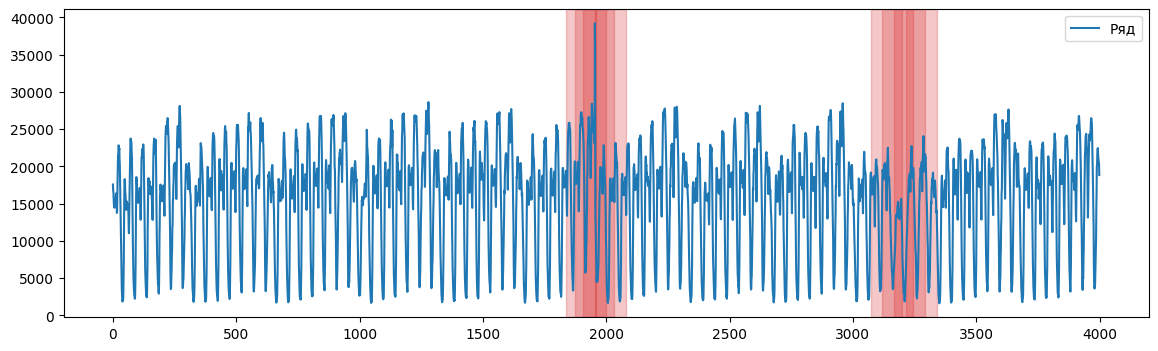

4.0 125 7


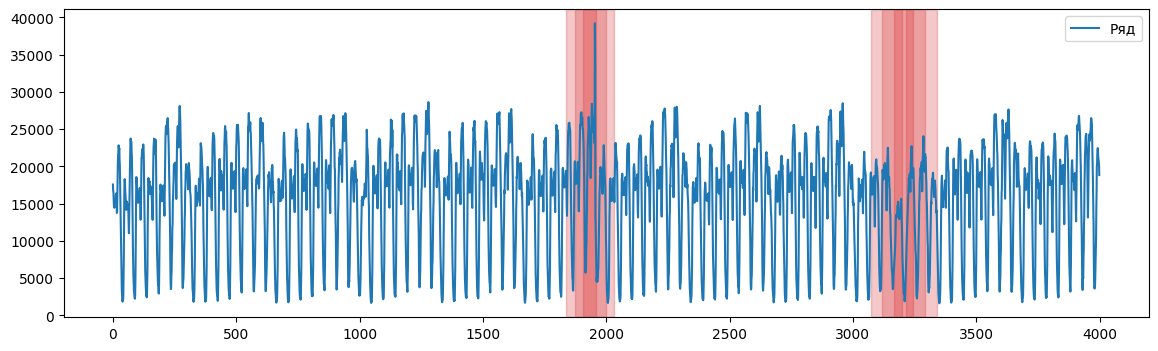

In [83]:
m_values = [25, 50, 65, 80, 95, 110, 125]
r_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

results = []

for m in m_values:
    for r in r_values:
        idxs, _, _ = DRAG(data, m, r)
      
        print(r, m, len(idxs))

        if len(idxs) == 0:
            break
        
        fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
        plt.plot(data[:],label='Ряд')
        plt.legend()
        
        ymin, ymax = ax.get_ylim()
        height = ymax - ymin
        
        for idx in idxs:
            rect = Rectangle((idx-0.5, ymin), m, height, alpha=0.25, color='C3', zorder=1)
            ax.add_patch(rect)

        plt.show()

In [84]:
data = nyc_taxi

In [85]:
m = 25
r = 2.5
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 6


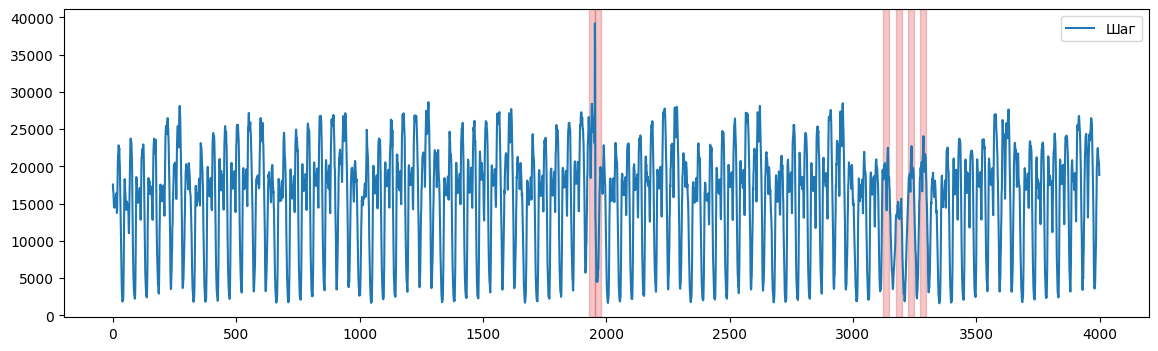

In [86]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.legend()

ymin, ymax = ax.get_ylim()
height = ymax - ymin

for idx in idxs:
    rect = Rectangle((idx-0.5, ymin), m, height, alpha=0.25, color='C3', zorder=1)
    ax.add_patch(rect)

#### **3.3 Поиск диссонансов с помощью алгоритма Merlin**

Как мы уже выяснили подбирать параметры для DRAG простым перебором не очень удобно. Для оптимизации данного процесса в статье [1] был предложен алгоритм Merlin для оптимального поиска подходящего порогового значения.

Условно мы можем разделить поиск диссонансов на три шага:

1. Поиск диссонансов минимальной длинны $minL$. На данном шаге $r = 2\sqrt{minL}$.
2. Поиск диссонансов следующих четырех длин. На данном шаге $r = 0.99 \cdot nndist_{m-1}$. Где $nndist_{m-1}$ - расстояние до ближайшего соседа предыдущего найденного диссонанса.
3. Поиск диссонансов всех 
оставшихся дли. $r = \mu - 2 \sigma$. Средние значение и стандартное отклонение вычисляются из расстояний 5 предыдущих диссонансов. н

[1] Nakamura T., Imamura M., Mercer R., Keogh E.J. MERLIN: parameter-free discovery of arbitrary length anomalies in massive time series archives. 20th IEEE Int. Conf. on Data Mining, ICDM 2020, Sorrento, Italy, November 17-20, 2020. pp. 1190-1195. IEEE (2020). https://doi.org/10.1109/ICDM50108.2020.00147

##### 3.3.1 Поиск диссонансов минимальной длинны

Вспомнил последовательность действий первого шага алгоритма:
![merlin-part-first](pics/first_part.png)

В данной работе мы внесем небольшое изменение, мы будем считать, что подпоследовательность может быть диссонансом только в том случае, если больше 75% точек, не входят в состав других диссонансов. 

In [ ]:
T = walk_run
m = 50
# сформируем массив метод для потенциальных кандидатов в диссонансы.
# после каждого найденного диссонанса, 
# мы будем исключать окружающие его подпоследовательности из числа потенциальных кандидатов,
# путем замены значений их меток на false
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)
# Количество диссонансов, которые мы будем искать
topK = 10


In [ ]:
dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = np.full((topK),-np.inf)
#первое прближение r
r = 2*np.sqrt(m)
minL = m
maxL = int(m+np.ceil(m*0.1))
#количество найденных диссонасов
cound_find_dis = 0

while dis_nnDist[cound_find_dis-1]<0 and cound_find_dis<topK:
    result = DRAG(data=T,m=minL,r=r, include =include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        #исключаем окружающие найденный диссонас 
        #подпоследовательности и числа потенциальных диссонасов
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis+=1
        if cound_find_dis>=topK:
            break
    r*=0.5

In [ ]:
maxL

In [ ]:
print('Количество найденных на первом этапе диссонансов:', cound_find_dis)

На первом шаге нам удалось выделить 2 диссонанса из 10 требуемых. 
Реализуйте, оставшиеся шаги алгоритма, чтобы найти оставшиеся диссонансы. 

![merlin-part-first](pics/second_part.png)


In [ ]:
# INSERT YOUR CODE

Найдите диссонансы набора такси NY. Визуализируйте найденные диссонансы для обоих наборов данных, сравните с результатами остальных методов. 


In [ ]:
# INSERT YOUR CODE